In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from scipy.stats import chi2

In [23]:
# Using Breast Cancer dataset (binary classification)

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
X.head()

Dataset Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (455, 30)
Testing samples: (114, 30)


In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [27]:
class LogisticRegressionScratch:

    def __init__(self, lr=0.01, iterations=1000):
        self.lr = lr
        self.iterations = iterations

    def fit(self, X, y):

        self.m, self.n = X.shape

        self.weights = np.zeros(self.n)
        self.bias = 0

        for _ in range(self.iterations):

            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = sigmoid(linear_model)

            dw = (1/self.m) * np.dot(X.T, (y_pred - y))
            db = (1/self.m) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_prob(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return sigmoid(linear_model)

    def predict(self, X):
        probabilities = self.predict_prob(X)
        return [1 if i > 0.5 else 0 for i in probabilities]

In [28]:
model = LogisticRegressionScratch(lr=0.01, iterations=2000)

model.fit(X_train, y_train)

In [29]:
y_pred = model.predict(X_test)
y_prob = model.predict_prob(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9912280701754386

Confusion Matrix
[[42  1]
 [ 0 71]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [31]:
def hosmer_lemeshow_test(y_true, y_prob, g=10):

    data = pd.DataFrame({'y': y_true, 'prob': y_prob})

    data['group'] = pd.qcut(data['prob'], g, duplicates='drop')

    obs = data.groupby('group')['y'].sum()
    exp = data.groupby('group')['prob'].sum()

    n = data.groupby('group')['y'].count()

    hl_stat = np.sum((obs - exp)**2 / (exp * (1 - exp/n)))

    p_value = 1 - chi2.cdf(hl_stat, g-2)

    return hl_stat, p_value

In [32]:
hl_stat, p_value = hosmer_lemeshow_test(y_test, y_prob)

print("Hosmer-Lemeshow Statistic:", hl_stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("Model fits the data well")
else:
    print("Model does not fit the data well")

Hosmer-Lemeshow Statistic: 1.5019106286374875
p-value: 0.992676058894685
Model fits the data well


/tmp/ipykernel_1268/2566940945.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs = data.groupby('group')['y'].sum()
/tmp/ipykernel_1268/2566940945.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp = data.groupby('group')['prob'].sum()
/tmp/ipykernel_1268/2566940945.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n = data.groupby('group')['y'].count()


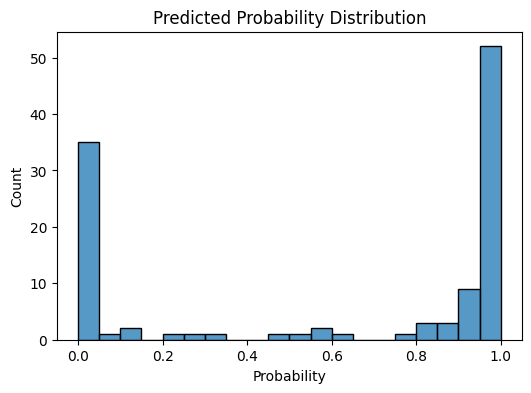

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(y_prob, bins=20)
plt.title("Predicted Probability Distribution")
plt.xlabel("Probability")
plt.show()

In [34]:
def log_loss(y_true, y_prob):
    epsilon = 1e-15
    y_prob = np.clip(y_prob, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob)
    )

    return loss

print("Log Loss:", log_loss(y_test, y_prob))

Log Loss: 0.07394211743240686


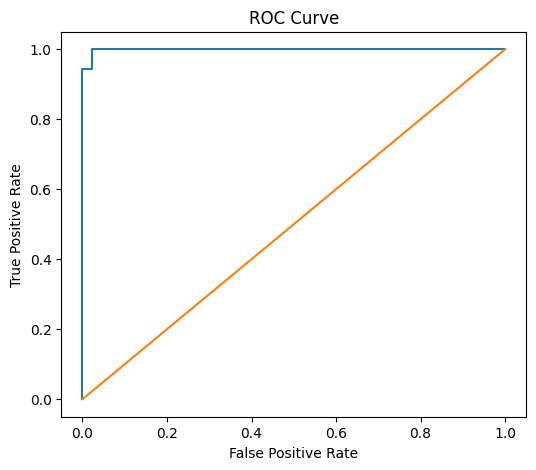

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [36]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.998689813298395


In [37]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5)

scores = []

for train_index, test_index in kf.split(X):

    X_train_k, X_test_k = X.iloc[train_index], X.iloc[test_index]
    y_train_k, y_test_k = y.iloc[train_index], y.iloc[test_index]

    scaler = StandardScaler()

    X_train_k = scaler.fit_transform(X_train_k)
    X_test_k = scaler.transform(X_test_k)

    model = LogisticRegressionScratch(lr=0.01, iterations=2000)

    model.fit(X_train_k, y_train_k)

    preds = model.predict(X_test_k)

    scores.append(accuracy_score(y_test_k, preds))

print("Cross Validation Accuracy:", np.mean(scores))

Cross Validation Accuracy: 0.9789318428815401


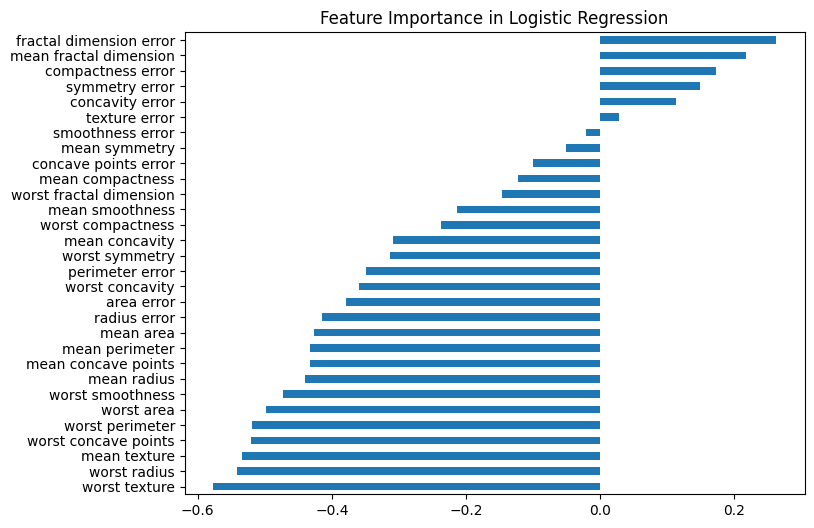

In [38]:
importance = pd.Series(model.weights, index=data.feature_names)

importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance in Logistic Regression")
plt.show()

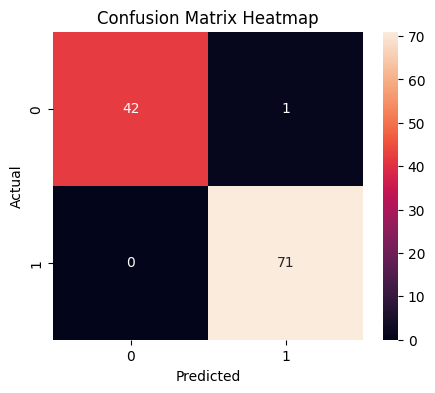

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

plt.show()

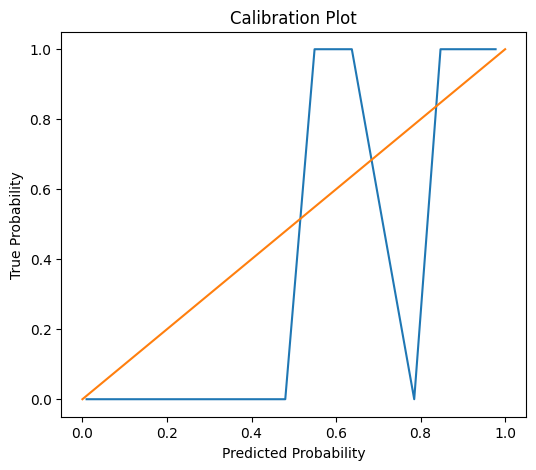

In [40]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1])

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")

plt.title("Calibration Plot")

plt.show()